# Step 5a — Kalman Smoother Evaluation

Validation-tuned Kalman smoother for oceanic gap reconstruction.

**How it works (why it beats the simple Kalman)**:
- Works in *along-track / cross-track* coordinates relative to the great-circle path
- Uses **both before AND after** ADS-B as measurements (Rauch-Tung-Striebel smoother)
- Tunes noise parameters on the validation set; reports on the test set

**Requirements**: Run `04_step4_dataset.ipynb` first to build the sequence datasets.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebook' else NOTEBOOK_DIR
sys.path.insert(0, str(NOTEBOOK_DIR))

CLEAN_ROOT   = PROJECT_ROOT / 'noel_part' / 'cleaned_data_final'
STEP4_DAT    = PROJECT_ROOT / 'artifacts' / 'step4_ml_dataset' / 'dataset'
STEP5K_ROOT  = PROJECT_ROOT / 'artifacts' / 'step5_kalman'

# ── Controls ─────────────────────────────────────────────────────────────────
RUN_KALMAN   = True     # set False to just review existing outputs
TUNING_GRID  = 'compact' # 'compact' (fast) or 'deep' (thorough)
MAX_FLIGHTS  = None     # None = all; set e.g. 100 for a quick test

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Step4 dataset: {STEP4_DAT}  exists={STEP4_DAT.exists()}')
print(f'Output root:   {STEP5K_ROOT}')
print(f'Run Kalman:    {RUN_KALMAN}')

Step4 dataset: c:\Users\marko\Desktop\AeroML3\artifacts\step4_ml_dataset\dataset  exists=True
Output root:   c:\Users\marko\Desktop\AeroML3\artifacts\step5_kalman
Run Kalman:    True


In [2]:
from step5_kalman_aeroml3 import KalmanConfig, run_step5_kalman

if RUN_KALMAN:
    if not STEP4_DAT.exists():
        raise FileNotFoundError(
            f'Missing step4 dataset at {STEP4_DAT}.\n'
            'Run notebook 04_step4_dataset.ipynb first.'
        )
    cfg = KalmanConfig(
        clean_root=CLEAN_ROOT,
        step4_dataset_root=STEP4_DAT,
        output_root=STEP5K_ROOT,
        tuning_grid=TUNING_GRID,
        max_flights_per_split=MAX_FLIGHTS,
        verbose=True,
    )
    summary = run_step5_kalman(cfg)
else:
    summary_path = STEP5K_ROOT / 'test_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError(
            f'No Kalman outputs at {STEP5K_ROOT}. Set RUN_KALMAN=True.')
    summary = json.loads(summary_path.read_text())
    print('Loaded existing Kalman summary.')

print(json.dumps(summary, indent=2))

Preparing train: 1540 flights
  100/1540 prepared
  200/1540 prepared
  300/1540 prepared
  400/1540 prepared
  500/1540 prepared
  600/1540 prepared
  700/1540 prepared
  800/1540 prepared
  900/1540 prepared
  1000/1540 prepared
  1100/1540 prepared
  1200/1540 prepared
  1300/1540 prepared
  1400/1540 prepared
  1500/1540 prepared
  usable: 1540
Preparing val: 315 flights
  100/315 prepared
  200/315 prepared
  300/315 prepared
  usable: 315
Preparing test: 291 flights
  100/291 prepared
  200/291 prepared
  usable: 291
Tuning on validation set: 36 candidates
  [1/36] new best=123.349 km  (std=200000.0, qa=0.0005, qc=0.5)
  [2/36] new best=116.750 km  (std=200000.0, qa=0.0005, qc=1.0)
  [3/36] new best=110.448 km  (std=200000.0, qa=0.0005, qc=2.0)
  [4/36] new best=106.737 km  (std=200000.0, qa=0.0005, qc=4.0)
  [8/36] new best=106.736 km  (std=200000.0, qa=0.001, qc=4.0)
  [12/36] new best=106.735 km  (std=200000.0, qa=0.005, qc=4.0)
Running final validation...
  validation final: 

In [3]:
# ── Load outputs ──────────────────────────────────────────────────────────────
preds        = np.load(STEP5K_ROOT / 'test_predictions.npz', allow_pickle=True)
per_flight   = pd.read_csv(STEP5K_ROOT / 'per_flight_metrics_test.csv')
tuning_df    = pd.read_csv(STEP5K_ROOT / 'val_tuning_results.csv')

pred_lat     = preds['pred_lat']
pred_lon     = preds['pred_lon']
true_lat     = preds['true_lat']
true_lon     = preds['true_lon']
baseline_lat = preds['baseline_lat']
baseline_lon = preds['baseline_lon']
mask         = preds['mask']
adsc_tau     = preds['adsc_tau']
segment_ids  = preds['segment_ids']
N = pred_lat.shape[0]
print(f'Loaded {N} test flights')
display(pd.DataFrame([['Kalman mean (km)', summary['test_summary']['kalman_mean_error_km']],
                       ['Kalman median (km)', summary['test_summary']['kalman_median_error_km']],
                       ['Baseline mean (km)', summary['test_summary']['baseline_mean_error_km']],
                       ['Baseline median (km)', summary['test_summary']['baseline_median_error_km']],
                       ['Improvement mean (%)', summary['test_summary']['improvement_mean_pct']],
                       ['Improvement median (%)', summary['test_summary']['improvement_median_pct']]],
                      columns=['metric', 'value']))

Loaded 291 test flights


,metric,value
0,Kalman mean (km),111.271805
1,Kalman median (km),88.226859
2,Baseline mean (km),140.272797
3,Baseline median (km),109.785492
4,Improvement mean (%),20.674708
5,Improvement median (%),19.637051


In [4]:
# ── Best tuning params ────────────────────────────────────────────────────────
print('Best Kalman parameters:')
display(pd.DataFrame([{'parameter': k, 'value': v}
                       for k, v in summary['selected_params'].items()]))

print('\nTop-10 validation candidates:')
display(tuning_df.head(10))

Best Kalman parameters:


,parameter,value
0,measurement_std_m,200000.000
1,accel_std_along_mps2,0.005
2,accel_std_cross_mps2,4.000



Top-10 validation candidates:


,candidate,measurement_std_m,accel_std_along_mps2,accel_std_cross_mps2,split,n_flights,kalman_mean_error_km,kalman_median_error_km,kalman_p90_error_km,baseline_mean_error_km,baseline_median_error_km,baseline_p90_error_km,improvement_mean_pct,improvement_median_pct
0,12,200000.0,0.0050,4.0,split,315,106.735219,86.434109,202.408159,139.255458,112.002914,262.441288,23.352937,22.828696
1,8,200000.0,0.0010,4.0,split,315,106.736470,86.429945,202.418359,139.255458,112.002914,262.441288,23.352039,22.832414
2,4,200000.0,0.0005,4.0,split,315,106.736627,86.429383,202.418719,139.255458,112.002914,262.441288,23.351926,22.832916
3,24,500000.0,0.0050,4.0,split,315,106.807676,85.937375,201.653719,139.255458,112.002914,262.441288,23.300905,23.272197
4,20,500000.0,0.0010,4.0,split,315,106.808504,85.940414,201.655150,139.255458,112.002914,262.441288,23.300311,23.269484
5,16,500000.0,0.0005,4.0,split,315,106.808608,85.940734,201.655041,139.255458,112.002914,262.441288,23.300236,23.269198
6,23,500000.0,0.0050,2.0,split,315,109.213543,87.445617,205.304991,139.255458,112.002914,262.441288,21.573241,21.925587
7,19,500000.0,0.0010,2.0,split,315,109.214299,87.452789,205.320797,139.255458,112.002914,262.441288,21.572698,21.919184
8,15,500000.0,0.0005,2.0,split,315,109.214393,87.454813,205.325141,139.255458,112.002914,262.441288,21.572630,21.917378
9,11,200000.0,0.0050,2.0,split,315,110.446617,89.161438,210.953584,139.255458,112.002914,262.441288,20.687765,20.393645


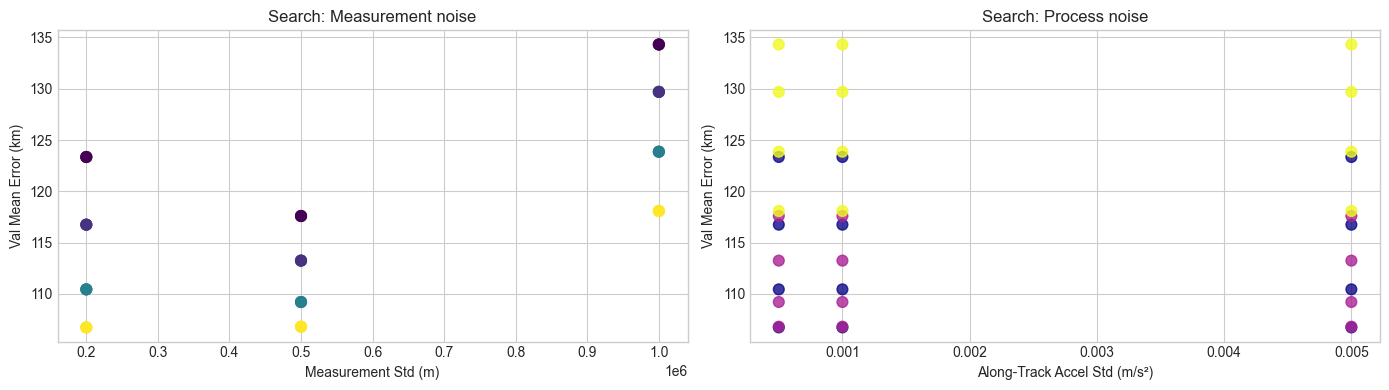

In [5]:
# ── Validation search scatter ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(tuning_df['measurement_std_m'], tuning_df['kalman_mean_error_km'],
                c=tuning_df['accel_std_cross_mps2'], cmap='viridis', s=60, alpha=0.8)
axes[0].set_xlabel('Measurement Std (m)'); axes[0].set_ylabel('Val Mean Error (km)')
axes[0].set_title('Search: Measurement noise')

axes[1].scatter(tuning_df['accel_std_along_mps2'], tuning_df['kalman_mean_error_km'],
                c=tuning_df['measurement_std_m'], cmap='plasma', s=60, alpha=0.8)
axes[1].set_xlabel('Along-Track Accel Std (m/s²)'); axes[1].set_ylabel('Val Mean Error (km)')
axes[1].set_title('Search: Process noise')
plt.tight_layout(); plt.show()

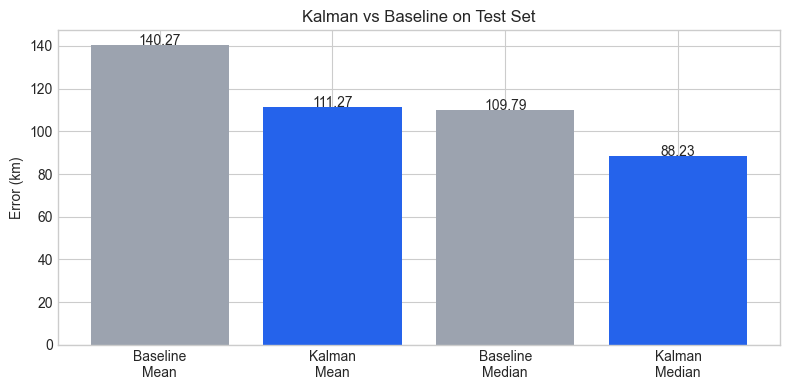

Improvement: mean=20.7%  median=19.6%


In [6]:
# ── Kalman vs Baseline bar chart ──────────────────────────────────────────────
ts = summary['test_summary']
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(['Baseline\nMean', 'Kalman\nMean', 'Baseline\nMedian', 'Kalman\nMedian'],
       [ts['baseline_mean_error_km'], ts['kalman_mean_error_km'],
        ts['baseline_median_error_km'], ts['kalman_median_error_km']],
       color=['#9ca3af','#2563eb','#9ca3af','#2563eb'])
ax.set_ylabel('Error (km)'); ax.set_title('Kalman vs Baseline on Test Set')
for i, v in enumerate([ts['baseline_mean_error_km'], ts['kalman_mean_error_km'],
                        ts['baseline_median_error_km'], ts['kalman_median_error_km']]):
    ax.text(i, v + 0.2, f'{v:.2f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()
print(f"Improvement: mean={ts['improvement_mean_pct']:.1f}%  median={ts['improvement_median_pct']:.1f}%")

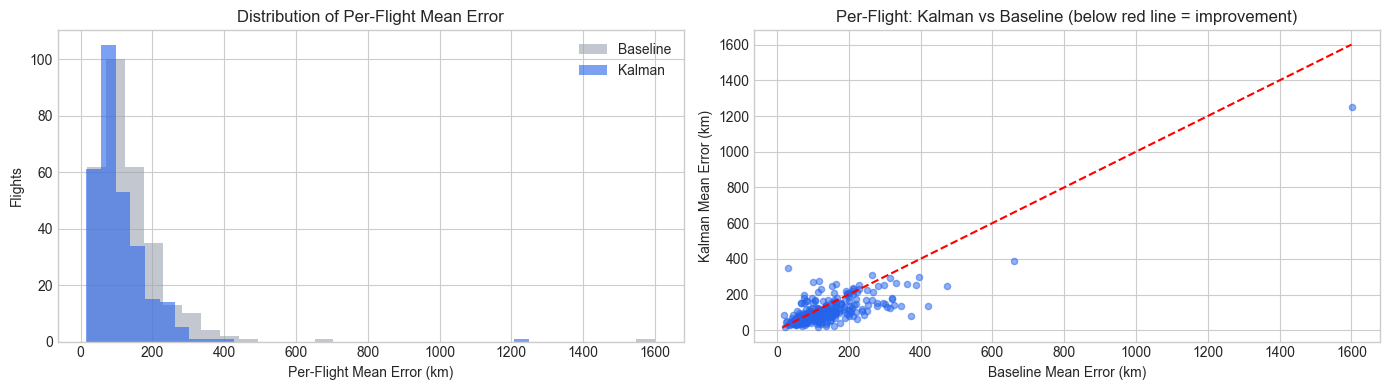

In [7]:
# ── Per-flight error distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(per_flight['baseline_mean_error_km'], bins=30, alpha=0.6, label='Baseline', color='#9ca3af')
axes[0].hist(per_flight['kalman_mean_error_km'],   bins=30, alpha=0.6, label='Kalman',   color='#2563eb')
axes[0].set_xlabel('Per-Flight Mean Error (km)'); axes[0].set_ylabel('Flights')
axes[0].set_title('Distribution of Per-Flight Mean Error'); axes[0].legend()

axes[1].scatter(per_flight['baseline_mean_error_km'], per_flight['kalman_mean_error_km'],
                alpha=0.5, color='#2563eb', s=20)
lims = [min(per_flight[['baseline_mean_error_km','kalman_mean_error_km']].min()),
        max(per_flight[['baseline_mean_error_km','kalman_mean_error_km']].max())]
axes[1].plot(lims, lims, 'r--', lw=1.5)
axes[1].set_xlabel('Baseline Mean Error (km)'); axes[1].set_ylabel('Kalman Mean Error (km)')
axes[1].set_title('Per-Flight: Kalman vs Baseline (below red line = improvement)')
plt.tight_layout(); plt.show()

In [8]:
# ── Best and worst Kalman flights ─────────────────────────────────────────────
best  = per_flight.sort_values('improvement_mean_pct', ascending=False).head(10)
worst = per_flight.sort_values('improvement_mean_pct', ascending=True).head(10)
print('Best Kalman improvements:')
display(best[['segment_id','n_waypoints','baseline_mean_error_km',
               'kalman_mean_error_km','improvement_mean_pct']])
print('Worst (Kalman hurt most):')
display(worst[['segment_id','n_waypoints','baseline_mean_error_km',
                'kalman_mean_error_km','improvement_mean_pct']])

Best Kalman improvements:


,segment_id,n_waypoints,baseline_mean_error_km,kalman_mean_error_km,improvement_mean_pct
165,step1_raw_2024-10-01_to_2024-11-01/20241004_a0...,64,115.110947,15.505941,86.529564
22,step1_raw_2023-10-01_to_2023-11-01/20231007_a0...,64,157.689468,23.900547,84.843285
235,step1_raw_20240611_20240612/20240612_39cf01_16...,64,136.618240,23.661915,82.680267
204,step1_raw_2024-12-01_to_2025-01-01/20241219_40...,64,374.650726,80.985771,78.383659
206,step1_raw_2024-12-01_to_2025-01-01/20241221_40...,64,174.886719,38.733227,77.852394
238,step1_raw_20240611_20240612/20240612_ab5c12_17...,64,136.767151,36.322437,73.442139
100,step1_raw_2024-04-01_to_2024-05-01/20240429_aa...,64,224.326111,62.323303,72.217545
110,step1_raw_2024-05-01_to_2024-06-01/20240527_a7...,64,121.677788,34.113289,71.964241
255,step1_raw_2025-07-01_to_2025-08-01/20250703_aa...,64,420.288177,133.697739,68.189034
68,step1_raw_2023-11-01_to_2023-12-01/20231112_a0...,64,110.874809,35.761139,67.746376


Worst (Kalman hurt most):


,segment_id,n_waypoints,baseline_mean_error_km,kalman_mean_error_km,improvement_mean_pct
225,step1_raw_20240312_20240313/20240312_7103d6_15...,64,31.878222,350.721283,-1000.190918
284,step1_raw_20250408_20250409/20250408_406b12_14...,64,19.264179,83.573059,-333.826202
213,step1_raw_2024-12-01_to_2025-01-01/20241225_40...,64,101.098022,268.318695,-165.404480
81,step1_raw_20230707_20230731/20230714_040103_10...,64,75.798424,198.766937,-162.230972
79,step1_raw_20230707_20230731/20230710_89617e_10...,64,74.379608,182.250961,-145.028137
59,step1_raw_2023-11-01_to_2023-12-01/20231109_06...,64,116.367516,277.789459,-138.717361
285,step1_raw_20250408_20250409/20250408_4d0104_13...,64,65.902634,153.397842,-132.764359
73,step1_raw_20230707_20230731/20230708_3965b0_11...,64,66.026237,153.363998,-132.277374
86,step1_raw_2024-02-01_to_2024-03-01/20240224_4b...,64,80.074394,163.086273,-103.668449
87,step1_raw_2024-02-01_to_2024-03-01/20240224_aa...,64,75.599091,151.877029,-100.897957


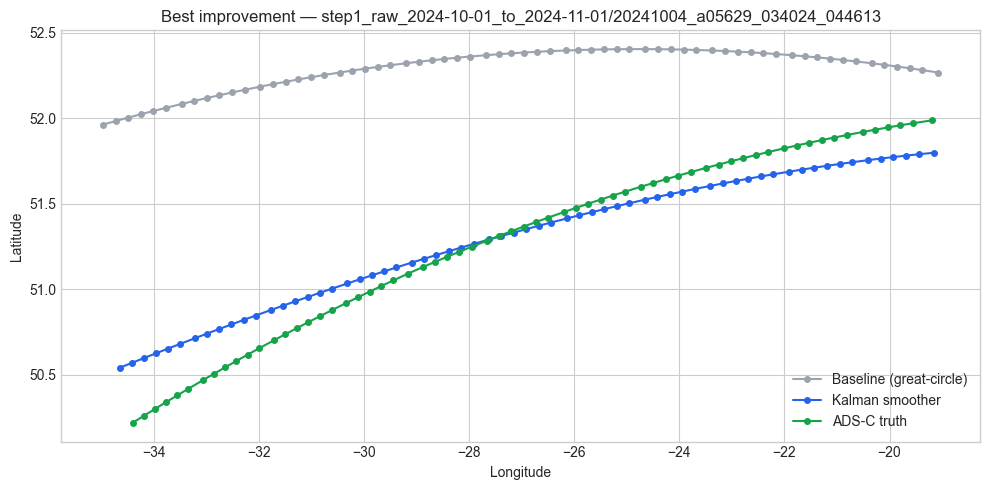

Baseline mean error: 115.11 km
Kalman  mean error:  15.51 km
Improvement:         86.5%


In [9]:
# ── Example: best Kalman flight ───────────────────────────────────────────────
flight_idx = int(per_flight['improvement_mean_pct'].idxmax())
seg_id = segment_ids[flight_idx]
valid  = mask[flight_idx] > 0

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(baseline_lon[flight_idx][valid], baseline_lat[flight_idx][valid],
        'o-', color='#9ca3af', ms=4, label='Baseline (great-circle)')
ax.plot(pred_lon[flight_idx][valid], pred_lat[flight_idx][valid],
        'o-', color='#2563eb', ms=4, label='Kalman smoother')
ax.plot(true_lon[flight_idx][valid], true_lat[flight_idx][valid],
        'o-', color='#16a34a', ms=4, label='ADS-C truth')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Best improvement — {seg_id}')
ax.legend(); plt.tight_layout(); plt.show()

row = per_flight.iloc[flight_idx]
print(f"Baseline mean error: {row['baseline_mean_error_km']:.2f} km")
print(f"Kalman  mean error:  {row['kalman_mean_error_km']:.2f} km")
print(f"Improvement:         {row['improvement_mean_pct']:.1f}%")

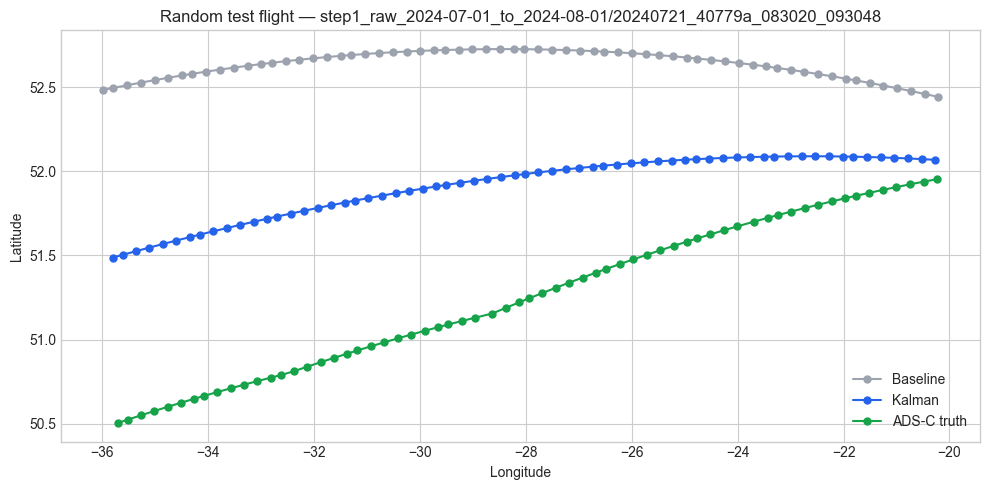

Baseline: 154.21 km  |  Kalman: 73.61 km  |  Improvement: 52.3%


In [10]:
# ── Example: random flight ────────────────────────────────────────────────────
import random
flight_idx = random.randint(0, N - 1)
seg_id = segment_ids[flight_idx]
valid  = mask[flight_idx] > 0

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(baseline_lon[flight_idx][valid], baseline_lat[flight_idx][valid],
        'o-', color='#9ca3af', ms=5, label='Baseline')
ax.plot(pred_lon[flight_idx][valid],     pred_lat[flight_idx][valid],
        'o-', color='#2563eb', ms=5, label='Kalman')
ax.plot(true_lon[flight_idx][valid],     true_lat[flight_idx][valid],
        'o-', color='#16a34a', ms=5, label='ADS-C truth')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Random test flight — {seg_id}')
ax.legend(); plt.tight_layout(); plt.show()

row = per_flight.iloc[flight_idx]
print(f"Baseline: {row['baseline_mean_error_km']:.2f} km  |  Kalman: {row['kalman_mean_error_km']:.2f} km  |  Improvement: {row['improvement_mean_pct']:.1f}%")

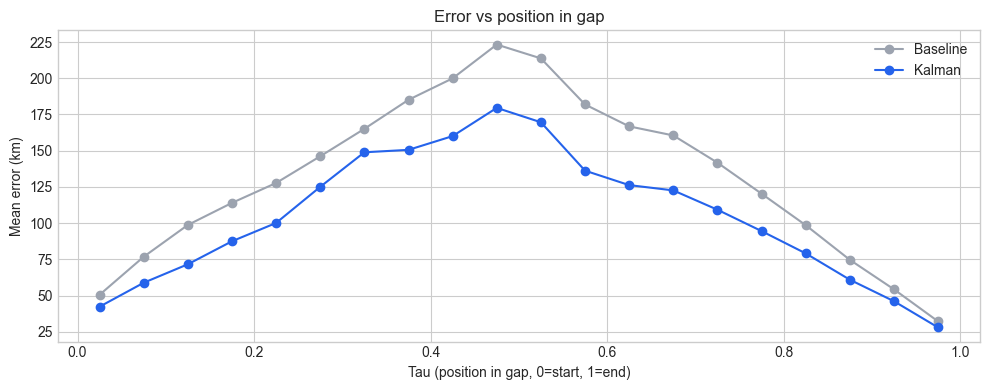

In [11]:
# ── Error vs tau (position within gap) ───────────────────────────────────────
tau_list, k_err_list, b_err_list = [], [], []
for fi in range(N):
    valid = mask[fi] > 0
    from step5_kalman_aeroml3 import haversine_m
    for j in np.where(valid)[0]:
        ke = haversine_m(pred_lat[fi,j], pred_lon[fi,j], true_lat[fi,j], true_lon[fi,j])
        be = haversine_m(baseline_lat[fi,j], baseline_lon[fi,j], true_lat[fi,j], true_lon[fi,j])
        tau_list.append(float(adsc_tau[fi, j]))
        k_err_list.append(ke / 1000.0)
        b_err_list.append(be / 1000.0)

tau_arr = np.array(tau_list)
k_arr   = np.array(k_err_list)
b_arr   = np.array(b_err_list)

# Bin by tau
bins = np.linspace(0, 1, 21)
centers = (bins[:-1] + bins[1:]) / 2
k_binned = [k_arr[(tau_arr >= bins[i]) & (tau_arr < bins[i+1])].mean() for i in range(len(bins)-1)]
b_binned = [b_arr[(tau_arr >= bins[i]) & (tau_arr < bins[i+1])].mean() for i in range(len(bins)-1)]

plt.figure(figsize=(10, 4))
plt.plot(centers, b_binned, 'o-', color='#9ca3af', label='Baseline')
plt.plot(centers, k_binned, 'o-', color='#2563eb', label='Kalman')
plt.xlabel('Tau (position in gap, 0=start, 1=end)')
plt.ylabel('Mean error (km)')
plt.title('Error vs position in gap')
plt.legend(); plt.tight_layout(); plt.show()